In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree

In [3]:
df_laurie = pd.read_csv('../data/Loan_approval_data_2025.csv')

In [4]:
df_laurie.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [5]:
df_laurie.dtypes

customer_id                    str
age                          int64
occupation_status              str
years_employed             float64
annual_income                int64
credit_score                 int64
credit_history_years       float64
savings_assets               int64
current_debt                 int64
defaults_on_file             int64
delinquencies_last_2yrs      int64
derogatory_marks             int64
product_type                   str
loan_intent                    str
loan_amount                  int64
interest_rate              float64
debt_to_income_ratio       float64
loan_to_income_ratio       float64
payment_to_income_ratio    float64
loan_status                  int64
dtype: object

In [6]:
df_laurie = df_laurie.drop(columns=['customer_id', 'product_type', 'interest_rate', 
                            'payment_to_income_ratio', 'loan_status'])

In [7]:
df_laurie.head()

,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_intent,loan_amount,debt_to_income_ratio,loan_to_income_ratio
0,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Business,600,0.423,0.023
1,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Home Improvement,53300,0.384,1.237
2,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Debt Consolidation,2100,0.377,0.101
3,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Business,2900,0.398,0.099
4,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Education,99600,0.195,1.565


In [8]:
df_laurie.shape

(50000, 15)

In [9]:
df_laurie.dtypes

age                          int64
occupation_status              str
years_employed             float64
annual_income                int64
credit_score                 int64
credit_history_years       float64
savings_assets               int64
current_debt                 int64
defaults_on_file             int64
delinquencies_last_2yrs      int64
derogatory_marks             int64
loan_intent                    str
loan_amount                  int64
debt_to_income_ratio       float64
loan_to_income_ratio       float64
dtype: object

In [10]:
print(df_laurie['occupation_status'].unique())
print(df_laurie['loan_intent'].unique())

<StringArray>
['Employed', 'Student', 'Self-Employed']
Length: 3, dtype: str
<StringArray>
[          'Business',   'Home Improvement', 'Debt Consolidation',
          'Education',           'Personal',            'Medical']
Length: 6, dtype: str


In [11]:
df_laurie['occupation_status'] = df_laurie['occupation_status'].map({'Employed': 1, 'Student': 0, 'Self-Employed': 2})
df_laurie['loan_intent'] = df_laurie['loan_intent'].map({'Business': 0, 'Home Improvement': 1, 'Debt Consolidation': 2, 'Education': 3, 'Personal': 4, 'Medical': 5})

In [12]:
df_laurie.head()

,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_intent,loan_amount,debt_to_income_ratio,loan_to_income_ratio
0,40,1,17.2,25579,692,5.3,895,10820,0,0,0,0,600,0.423,0.023
1,33,1,7.3,43087,627,3.5,169,16550,0,1,0,1,53300,0.384,1.237
2,42,0,1.1,20840,689,8.4,17,7852,0,0,0,2,2100,0.377,0.101
3,53,0,0.5,29147,692,9.8,1480,11603,0,1,0,0,2900,0.398,0.099
4,32,1,12.5,63657,630,7.2,209,12424,0,0,0,3,99600,0.195,1.565


In [26]:
df_laurie.isna().sum()

age                        0
occupation_status          0
years_employed             0
annual_income              0
credit_score               0
credit_history_years       0
savings_assets             0
current_debt               0
defaults_on_file           0
delinquencies_last_2yrs    0
derogatory_marks           0
loan_intent                0
loan_amount                0
debt_to_income_ratio       0
loan_to_income_ratio       0
dtype: int64

In [28]:
def calculate_risk_score(row):
    score = 0

    if row['credit_score'] < 580:
        score += 3
    elif row['credit_score'] < 600:
        score += 2
    elif row['credit_score'] < 687:
        score += 1


    if row['debt_to_income_ratio'] >= 0.50:
        score += 3
    elif row['debt_to_income_ratio'] >= 0.40:
        score += 2
    elif row['debt_to_income_ratio'] >= 0.30:
        score += 1

    if row['loan_to_income_ratio'] > 1.01:
        score += 2
    elif row['loan_to_income_ratio'] >= 0.62:
        score += 1


    if row['defaults_on_file'] == 1:
        score += 4


    if row['delinquencies_last_2yrs'] >= 3:
        score += 2
    elif row['delinquencies_last_2yrs'] >= 1:
        score += 1


    if row['derogatory_marks'] >= 2:
        score += 3
    elif row['derogatory_marks'] == 1:
        score += 2
        

    if row['annual_income'] < 25000:
        score += 1

    return score

In [29]:
df_laurie['risk_score'] = df_laurie.apply(calculate_risk_score, axis=1)

In [30]:
df_laurie['risk_score'].value_counts().sort_index()

risk_score
0     2340
1     6159
2     8862
3     8971
4     7501
5     5610
6     3853
7     2392
8     1592
9     1069
10     714
11     431
12     268
13     149
14      63
15      21
16       5
Name: count, dtype: int64

In [33]:
def assign_risk(score):
    if score <= 2:
        return 0
    elif score <= 5:
        return 1
    return 2

df_laurie['risk_level'] = df_laurie['risk_score'].apply(assign_risk)

In [34]:
df_laurie['risk_level'].value_counts().sort_index()

risk_level
0    17361
1    22082
2    10557
Name: count, dtype: int64

In [35]:
X = df_laurie.drop(columns=['risk_score', 'risk_level'])
y = df_laurie['risk_level']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
arbol_clasificacion = DecisionTreeClassifier(criterion = 'gini', max_depth=7, random_state=42)

In [39]:
arbol_clasificacion.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [40]:
y_pred = arbol_clasificacion.predict(X_test)

In [41]:
precision = accuracy_score(y_test, y_pred)
print('Precisión del arbol: ', precision)

Precisión del arbol:  0.9285


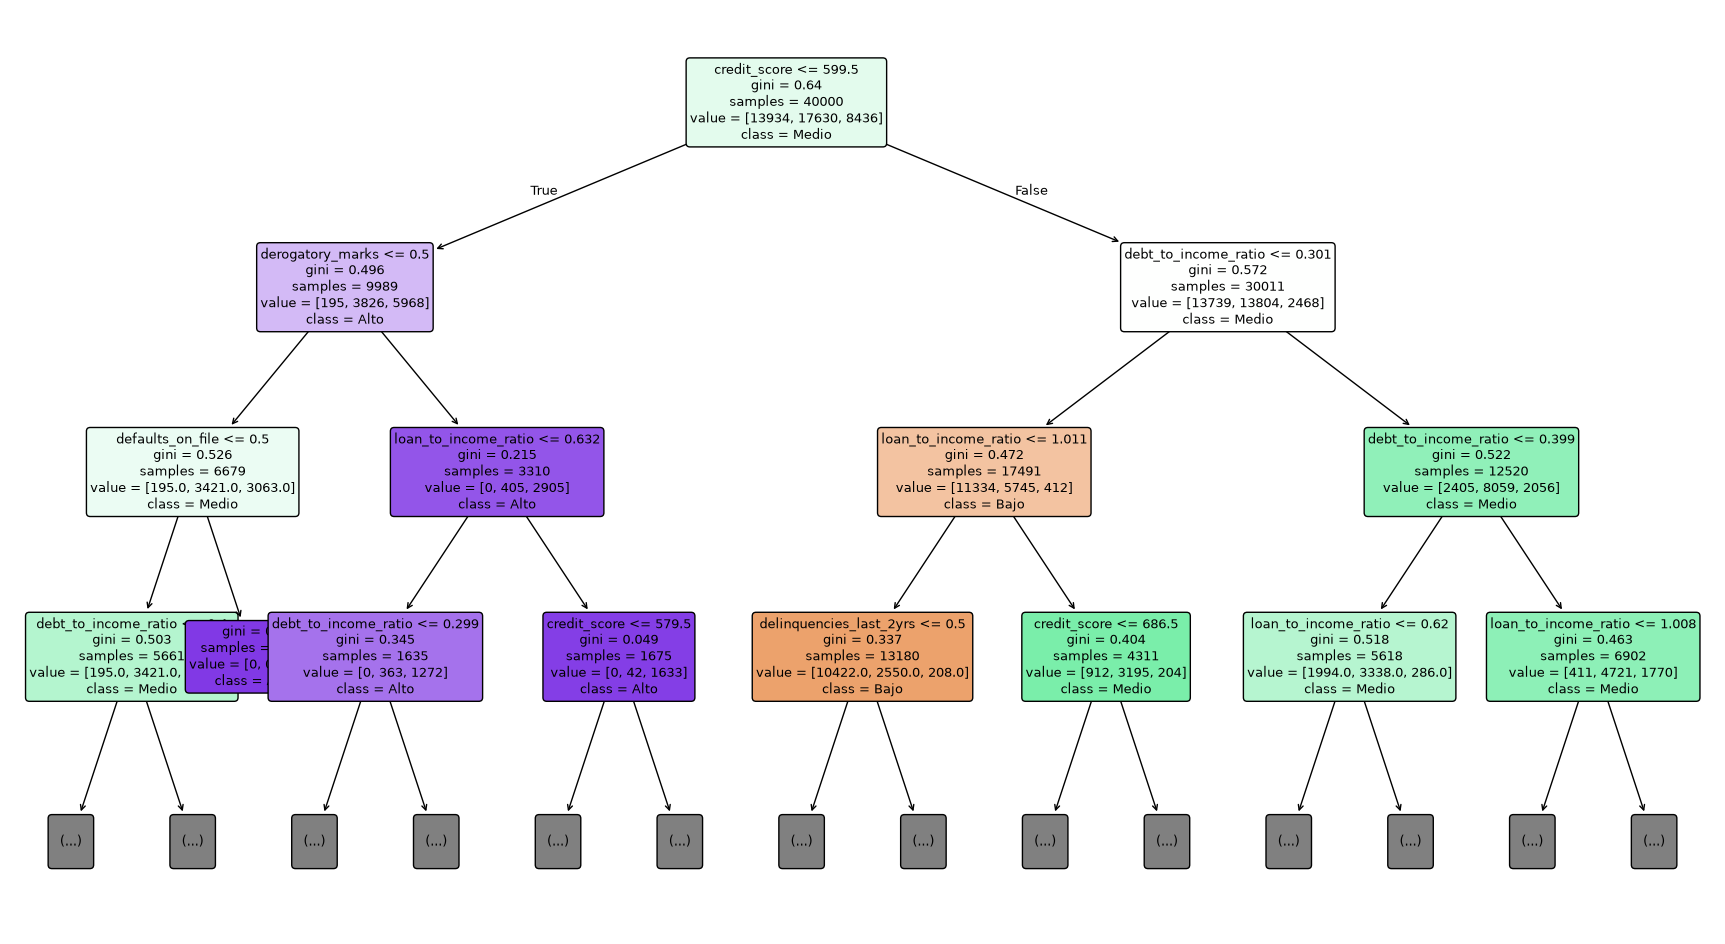

In [ ]:
plt.figure(figsize=(22,12))

tree.plot_tree(
    arbol_clasificacion,
    feature_names=X.columns,
    class_names=['Bajo','Medio','Alto'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.show()

In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96      3427
           1       0.89      0.96      0.93      4452
           2       0.95      0.84      0.89      2121

    accuracy                           0.93     10000
   macro avg       0.94      0.91      0.92     10000
weighted avg       0.93      0.93      0.93     10000



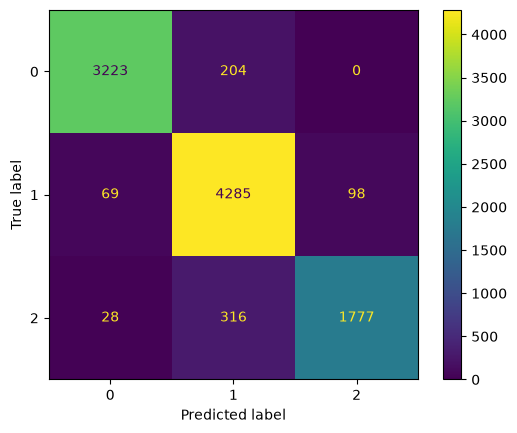

In [49]:
cm = confusion_matrix(y_test, y_pred)
dis = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=arbol_clasificacion.classes_)
dis.plot()
plt.show()

In [ ]:
importancias = pd.Series(arbol_clasificacion.feature_importances_, index=X.columns).sort_values(ascending=False)

top_5_features = importancias.head(5)

print('Importancia de las caracteristicas:')
print(importancias)

print('\nCinco caracteristicas principales:')
print(top_5_features)

Importancia de las caracteristicas:
credit_score               0.268146
loan_to_income_ratio       0.223076
debt_to_income_ratio       0.180730
delinquencies_last_2yrs    0.116638
derogatory_marks           0.084711
annual_income              0.064402
defaults_on_file           0.062118
loan_amount                0.000116
years_employed             0.000063
age                        0.000000
occupation_status          0.000000
savings_assets             0.000000
credit_history_years       0.000000
current_debt               0.000000
loan_intent                0.000000
dtype: float64

Cinco caracteristicas principales:
credit_score               0.268146
loan_to_income_ratio       0.223076
debt_to_income_ratio       0.180730
delinquencies_last_2yrs    0.116638
derogatory_marks           0.084711
dtype: float64


In [61]:
model_bundle = {
    'model': arbol_clasificacion,
    'feature_names': X.columns.tolist(),
    'top_5_features': top_5_features,
    'category_mappings': {
        'occupation_status': {
            'Employed': 1,
            'Student': 0,
            'Self-Employed': 2
        },
        'loan_intent': {
            'Business': 0,
            'Home Improvement': 1,
            'Debt Consolidation': 2,
            'Education': 3,
            'Personal': 4,
            'Medical': 5
        }
    },
    'risk_labels': {
        0: 'Bajo',
        1: 'Medio',
        2: 'Alto'
    }
}

pd.to_pickle(
    model_bundle,
    '../artifacts/credit_risk_model.pkl'
)

print('Modelo guardado correctamente.')

Modelo guardado correctamente.


In [57]:
loaded_bundle = pd.read_pickle(
    '../models/credit_risk_model.pkl'
)

loaded_model = loaded_bundle['model']
loaded_features = loaded_bundle['feature_names']
loaded_top_5 = loaded_bundle['top_5_features']

print('Columnas:', loaded_features)
print('Top 5:\n', loaded_top_5)

Columnas: ['age', 'occupation_status', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_intent', 'loan_amount', 'debt_to_income_ratio', 'loan_to_income_ratio']
Top 5:
 credit_score               0.268146
loan_to_income_ratio       0.223076
debt_to_income_ratio       0.180730
delinquencies_last_2yrs    0.116638
derogatory_marks           0.084711
dtype: float64


In [60]:
cliente = X.iloc[[0]].copy()

cliente = cliente[loaded_features]

prediccion = int(
    loaded_model.predict(cliente)[0]
)

print('Categoría predicha:', prediccion)
print(cliente)


Categoría predicha: 1
   age  occupation_status  years_employed  annual_income  credit_score  \
0   40                  1            17.2          25579           692   

   credit_history_years  savings_assets  current_debt  defaults_on_file  \
0                   5.3             895         10820                 0   

   delinquencies_last_2yrs  derogatory_marks  loan_intent  loan_amount  \
0                        0                 0            0          600   

   debt_to_income_ratio  loan_to_income_ratio  
0                 0.423                 0.023  
